### Discrete approximation of the Wiener process (Brownian motion) on [0, 1].


The goal of this homework is to implement an approximation of a Wiener process and investigate its properties.


We will use grid points $t_k = \frac{k}{n}$,  $k = 1, \ldots , n$

Let $\Delta_t := \frac{1}{n}$

White noise is approximated as $\xi_{t_k} \sim N(0, \frac{1}{\Delta_t})$ i.i.d. (so that $\xi_{t_k} \cdot \Delta_t$ has variance $\Delta_t$)

Wiener process is approximated with:  $W^{(n)}_t = \sum_{k=1}^{\lfloor n t\rfloor} \xi_{t_k} \cdot \Delta_t$

As $n \to \infty$, $W^{(n)}_t \to W_t \sim N(0, t)$, the value of the Wiener process at time $t$.

In this notebook you will:

1. implement `simulate_wiener` to build $W^{(n)}$ on the grid for $m$ independent trajectories,
2. empirically check $E[W^{(n)}_t] = 0$ and $\mathrm{Var}(W^{(n)}_t) = t$ against the theoretical values,
3. plot sample paths together with the $\pm 1.96\sqrt{t}$ 95% envelope,
4. demonstrate that the increment $W(a) - W(b) \sim N(0, a-b)$ for $a > b$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats


Implement the simulate_wiener(n: int, m: int) -> tuple[np.ndarray, np.ndarray] function.

It simulates m trajectories of the discrete Wiener approximation $W^{(n)}_t$ on the grid $t_k = k/n$, $k = 1, ..., n$.

    Parameters
    ----------
    n : number of grid points on [0, 1] (Delta_t = 1/n)
    m : number of independent trajectories
    
    Returns
    -------
    t : shape (n,), the grid t_1, ..., t_n
    W : shape (m, n), W[i, k-1] = W^{(n)}_{t_k} of trajectory i
    



In [2]:
def simulate_wiener(n: int, m: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate m trajectories of the discrete Wiener approximation W^{(n)}_t
    on the grid t_k = k/n, k = 1, ..., n.

    Parameters
    ----------
    n : number of grid points on [0, 1] (Delta_t = 1/n)
    m : number of independent trajectories

    Returns
    -------
    t : shape (n,), the grid t_1, ..., t_n
    W : shape (m, n), W[i, k-1] = W^{(n)}_{t_k} of trajectory i
    """

    rng = np.random.default_rng()

    t = np.linspace(0, 1, n, endpoint=False)
    W = np.cumsum(rng.normal(loc=0, scale=1/np.sqrt(n), size=(m, n)), axis=1)
    return t, W


Run the simulate_wiener(n: int, m: int) function for

n = 1_000 grid points per trajectory

m = 10_000       number of trajectories


In [3]:
n = 1_000        # grid points per trajectory (Delta_t = 1/n)
m = 10_000        # number of trajectories

t, W = simulate_wiener(n=n, m=m)

print(t.shape)
print(W.shape)

(1000,)
(10000, 1000)


Calculate the empirical mean and variance and the theoretical mean and variance values at the time points t.



In [4]:

empirical_mean = W.mean(axis=0)     # shape (n,)
print(empirical_mean.shape)

empirical_var = W.var(axis=0, ddof=1)
print(empirical_var.shape)

theoretical_mean = np.zeros(n)
print(theoretical_mean.shape)

theoretical_var = t
print(theoretical_var.shape)

(1000,)
(1000,)
(1000,)
(1000,)


Implement `print_table` to print the empirical and theoretical mean and variance values as a table, for time points [0.1, 0.25, 0.5, 0.75, 1.0].


In [5]:
def print_table(t,empirical_mean, empirical_var, check_times = [0.1, 0.25, 0.5, 0.75, 1.0]):
  """
  Parameters
    t: shape (n,)
    empirical_mean : shape (n,)
    empirical_var : shape (n,)
  """
  header = f"{'t':>6} | {'E[W_n(t)]':>12} | {'theory=0':>10} | {'Var[W_n(t)]':>13} | {'theory=t':>10}"
  print(header)
  print("-" * len(header))
  for ct in check_times:
    idx = int(np.argmin(np.abs(t - ct)))
    print(
        f"{ct:6.3f} | {empirical_mean[idx]:12.5f} | {0.0:10.3f} | "
        f"{empirical_var[idx]:13.5f} | {ct:10.3f}"
    )

print_table(t, empirical_mean, empirical_var, check_times = [0.1, 0.25, 0.5, 0.75, 1.0])

     t |    E[W_n(t)] |   theory=0 |   Var[W_n(t)] |   theory=t
---------------------------------------------------------------
 0.100 |      0.00267 |      0.000 |       0.10139 |      0.100
 0.250 |      0.00542 |      0.000 |       0.24846 |      0.250
 0.500 |      0.00225 |      0.000 |       0.49583 |      0.500
 0.750 |      0.00158 |      0.000 |       0.73840 |      0.750
 1.000 |      0.00304 |      0.000 |       0.99692 |      1.000


Plot 25 generated sample paths from the Wiener process.

Also plot the 95% envelope, that is the `1.96 * np.sqrt(t)` and `-1.96 * np.sqrt(t)` curves that contain 95% of the Gaussian trajectories at any $t$.


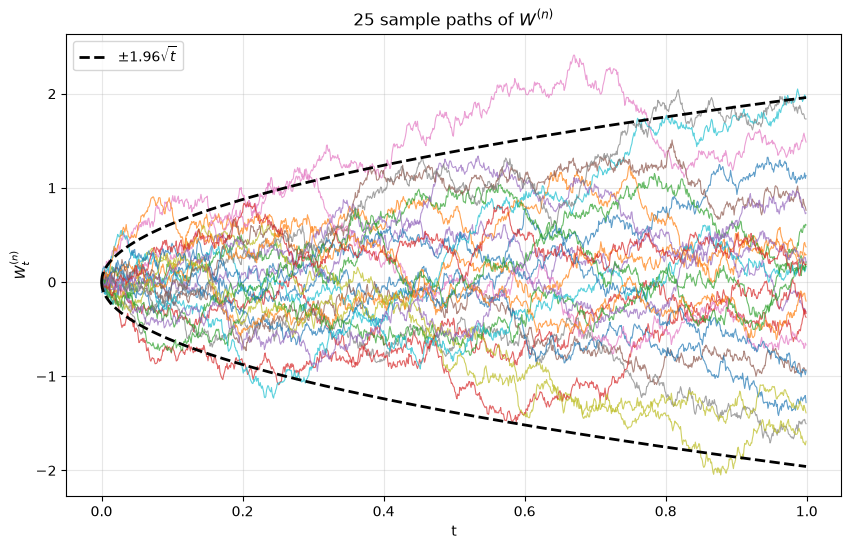

In [6]:
def plot_paths(t, W, n_show = 25):

  """
  Parameters
    t : shape (n,), the grid t_1, ..., t_n
    W : shape (m, n), W[i, k-1] = W^{(n)}_{t_k} of trajectory i
    n_show : int, number of sample paths to plot
  """

  n_show = min(n_show, W.shape[0])
  plt.figure(figsize=(10, 6))

  for i in range(n_show):
    plt.plot(t, W[i], lw=0.8, alpha=0.7)

  envelope = 1.96 * np.sqrt(t)
  plt.plot(t, envelope, "k--", lw=2, label=r"$\pm 1.96\sqrt{t}$")
  plt.plot(t, -envelope, "k--", lw=2)

  plt.title(f"{n_show} sample paths of $W^{{(n)}}$")
  plt.xlabel("t")
  plt.ylabel("$W^{(n)}_t$")
  plt.legend(loc="upper left")
  plt.grid(True, alpha=0.3)

  plt.savefig("../written/figures/plot_paths_output.png")
  plt.show()

plot_paths(t, W, n_show = 25)


For a=0.7,b=0.3, demonstrate that for the discrete Wiener approximation $W^{(n)}$ built by simulate_wiener() the increment

$$W_a - W_b  \sim  N(0, a - b)  \quad \text{ for } a > b$$

i.e. Brownian increments are Gaussian with mean 0 and variance equal to the
length of the time interval, independent of where that interval sits in [0,1].


               |    empirical |  theoretical
--------------------------------------------
          mean |     -0.00479 |      0.00000
      variance |      0.39814 |      0.40000


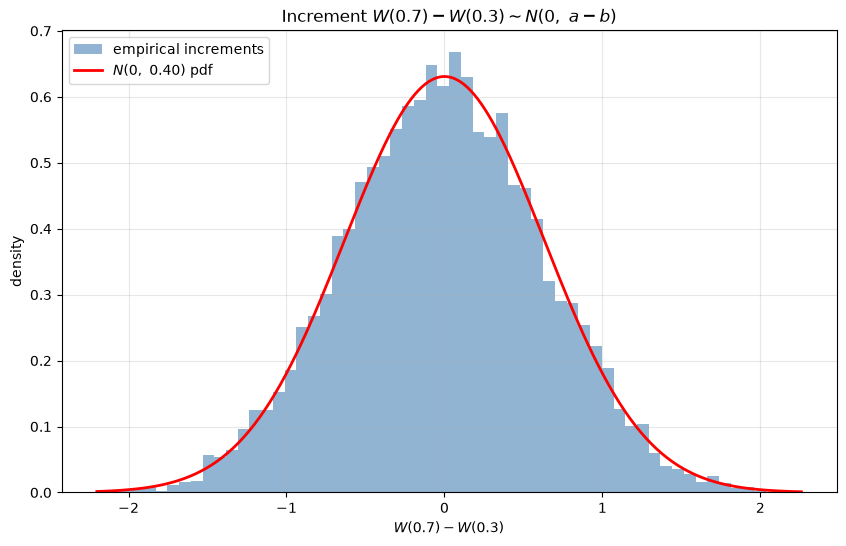

In [7]:
def calc_increments(t,W,a=0.7,b=0.3):
  """
  * calculate the W(a)-W(b) increments.
  * Print their empirical and theoretical mean and variance
  * Plot a histogram of the W(a)-W(b) increments
  * Plot the theoretical Gaussian pdf of W(a)-W(b)

  Parameters
  ----------
  t : shape (n,), the grid t_1, ..., t_n
  W : shape (m, n), W[i, k-1] = W^{(n)}_{t_k} of trajectory i
  a : float
  b : float

  """

  idx_a = int(np.argmin(np.abs(t - a)))
  idx_b = int(np.argmin(np.abs(t - b)))
  incs = W[:, idx_a] - W[:, idx_b]

  # empirical moments
  emp_mean = incs.mean()
  emp_var = incs.var(ddof=1)

  # theoretical moments: W(a) - W(b) ~ N(0, a - b)
  # use the actual grid times to match the discrete approximation
  theo_mean = 0.0
  theo_var = t[idx_a] - t[idx_b]
  theo_std = np.sqrt(theo_var)

  print(f"{'':>14} | {'empirical':>12} | {'theoretical':>12}")
  print("-" * 44)
  print(f"{'mean':>14} | {emp_mean:12.5f} | {theo_mean:12.5f}")
  print(f"{'variance':>14} | {emp_var:12.5f} | {theo_var:12.5f}")

  plt.figure(figsize=(10, 6))
  plt.hist(incs, bins=60, density=True, alpha=0.6,
           color="steelblue", label="empirical increments")

  xs = np.linspace(incs.min(), incs.max(), 400)
  pdf = stats.norm.pdf(xs, loc=theo_mean, scale=theo_std)
  plt.plot(xs, pdf, "r-", lw=2,
           label=fr"$N(0,\ {theo_var:.2f})$ pdf")

  plt.title(fr"Increment $W({a}) - W({b}) \sim N(0,\ a-b)$")
  plt.xlabel(fr"$W({a}) - W({b})$")
  plt.ylabel("density")
  plt.legend(loc="upper left")
  plt.grid(True, alpha=0.3)

  plt.savefig("../written/figures/calc_increments_output.png")
  plt.show()

calc_increments(t,W,a=0.7,b=0.3)